<a href="https://colab.research.google.com/github/BiswarupMukherjee1/spacecraft-pose-failure-detection/blob/main/Exp5_uncertainty_across_domain_gap.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Aleatoric and epistemic uncertainty across the domain gap

Biswarup Mukherjee

The study in Experiments 1, 2 and 3 used the RANSAC inlier ratio as a confidence signal and found it
poorly calibrated for the learned detector. That signal is free, but it is a
by-product of a solver rather than a statement about how wrong the answer is, and it
has no units. Therefore, a navigation filter needs a covariance.

This experiment trains a network on SPEED+ data that predicts its own error, and splits it
into the two components that are usually distinguished:

**Aleatoric** uncertainty is noise in the observation. A dark, saturated or blurred
image carries less information about the pose, and no amount of extra training data
removes that. It is predicted directly by a variance output per axis, trained with a
Gaussian negative log-likelihood (Kendall and Gal, NeurIPS 2017).

**Epistemic** uncertainty is the model's own ignorance, from having seen limited data.
It is estimated with Monte Carlo dropout (Gal and Ghahramani, ICML 2016): dropout is
left active at inference and the same image is passed repeatedly, so the spread across
passes is the model disagreeing with itself.

Epistemic uncertainty requires no labels. If it rises on lightbox and sunlamp relative
to synthetic, the model is signalling that it is outside the distribution it was
trained on, which is a signal available in flight where ground truth is not.

The SPEED+ v2 archive does include labels for both hardware-in-the-loop domains,
released after the pose estimation competition SPEC2021 closed. This test therefore has an independent check: the
prediction made without labels can be compared against the error measured with them in
Experiment 4.

## SPEED+

In [ ]:
!pip install -q opencv-contrib-python transformers 2>&1 | tail -2

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import sys, os
CODE = "/content/drive/MyDrive/SENER_PROJ2/code"
if CODE not in sys.path:
    sys.path.insert(0, CODE)
print("modules found:", sorted(f for f in os.listdir(CODE) if f.endswith(".py")))

Mounted at /content/drive
modules found: ['exp6_ekf_mc.py', 'exp7_efficiency.py', 'pose_models.py', 'sc_common.py', 'speedplus_data.py', 'speedplus_fetch.py']


In [ ]:
import os, time, numpy as np, torch, cv2, matplotlib.pyplot as plt
import speedplus_data as SP
import pose_models as PM
import speedplus_fetch as SF

SEED = 0
np.random.seed(SEED); torch.manual_seed(SEED)
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)


ZIP            = "/content/drive/MyDrive/SENER_PROJ2/data/speedplusv2.zip"
SPEEDPLUS_ROOT = "/content/speedplus"
IMG_SIZE       = 224
N_TRAIN, N_VAL, N_HIL = 8000, 1500, 600


if not os.path.exists(os.path.join(SPEEDPLUS_ROOT, "camera.json")):
    assert SF.verify_zip(ZIP), "archive missing or incomplete: re-run the wget with -c"
    SF.extract_subset(ZIP, SPEEDPLUS_ROOT,
                      n_synth_train=N_TRAIN, n_synth_val=N_VAL, n_hil=N_HIL)
SF.summarise(SPEEDPLUS_ROOT)

K, dist, (W, H) = SP.load_camera(SPEEDPLUS_ROOT)
print("camera focal lengths:", np.diag(K)[:2].round(1), " native image size:", (W, H))

train_recs = SP.load_split(SPEEDPLUS_ROOT, "synthetic", "train")
val_recs   = SP.load_split(SPEEDPLUS_ROOT, "synthetic", "validation")
print(f"synthetic: {len(train_recs)} train, {len(val_recs)} validation (labelled)")

hil = {}
for dom in ["lightbox", "sunlamp"]:
    try:
        r = SP.load_split(SPEEDPLUS_ROOT, dom, "test")
        hil[dom] = r
        print(f"{dom}: {len(r)} images, labelled = {r[0]['t'] is not None}")
    except Exception as e:
        print(f"{dom}: not present ({type(e).__name__})")

device: cuda
archive size: 16.93 GB (expected about 16.9)
archive opens correctly, 69504 entries
archive root: 'speedplusv2/'
  wrote camera.json
  wrote synthetic/train.json
  wrote synthetic/validation.json
  wrote lightbox/test.json
  wrote sunlamp/test.json
    synthetic/train.json: 1000 extracted so far
    synthetic/train.json: 2000 extracted so far
    synthetic/train.json: 3000 extracted so far
    synthetic/train.json: 4000 extracted so far
    synthetic/train.json: 5000 extracted so far
    synthetic/train.json: 6000 extracted so far
    synthetic/train.json: 7000 extracted so far
    synthetic/train.json: 8000 extracted so far
  synthetic/train.json: 8000 new  (target 8000)
    synthetic/validation.json: 1000 extracted so far
  synthetic/validation.json: 1500 new  (target 1500)
  lightbox/test.json: 600 new  (target 600)
  sunlamp/test.json: 600 new  (target 600)
camera.json     : found
synthetic/train      :  47966 records in json,   9500 images on disk
synthetic/validation

    8000 of 47966 images present on disk
    loaded 2000/8000
    loaded 4000/8000
    loaded 6000/8000
    loaded 8000/8000
    1500 of 11994 images present on disk
    600 of 6740 images present on disk
    600 of 2791 images present on disk
loaded in 143 s: train (8000, 1, 224, 224), val (1500, 1, 224, 224), lightbox 600, sunlamp 600
range in the training set: 2.3 to 10.0 m


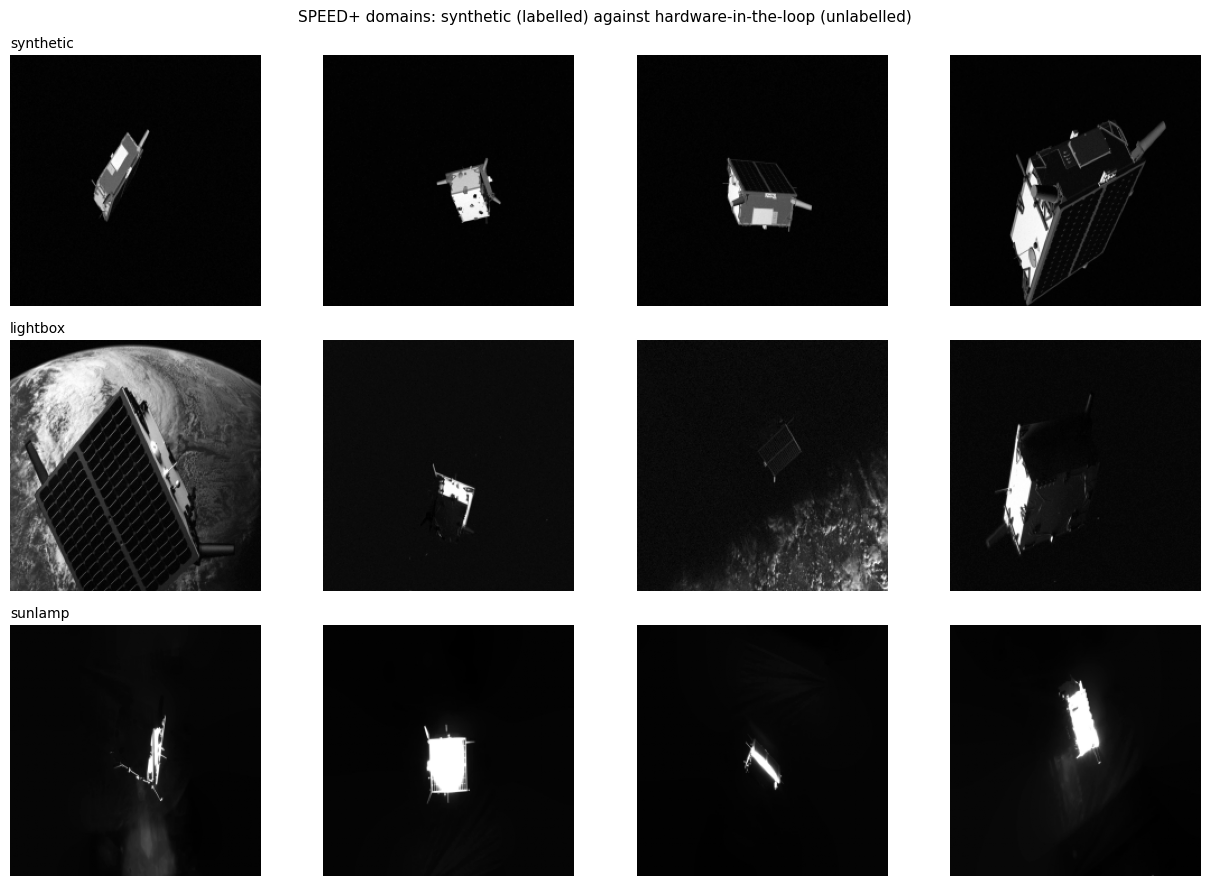

In [ ]:
t0 = time.time()
Xtr, Ttr, Qtr = SP.build_arrays(train_recs, size=IMG_SIZE, limit=N_TRAIN, labelled=True)
Xva, Tva, Qva = SP.build_arrays(val_recs,   size=IMG_SIZE, limit=N_VAL,  labelled=True)
Xhil = {d: SP.build_arrays(r, size=IMG_SIZE, limit=N_HIL, labelled=False)[0]
        for d, r in hil.items()}
print(f"loaded in {time.time()-t0:.0f} s: train {Xtr.shape}, val {Xva.shape}, "
      + ", ".join(f"{d} {v.shape[0]}" for d, v in Xhil.items()))
print(f"range in the training set: {np.linalg.norm(Ttr,axis=1).min():.1f} to "
      f"{np.linalg.norm(Ttr,axis=1).max():.1f} m")

n_show = 4
doms = [("synthetic", Xva)] + list(Xhil.items())
fig, axes = plt.subplots(len(doms), n_show, figsize=(3.2*n_show, 3.0*len(doms)), squeeze=False)
for r, (name, Xd) in enumerate(doms):
    for c in range(n_show):
        axes[r][c].imshow(Xd[min(c, len(Xd)-1), 0], cmap="gray")
        axes[r][c].axis("off")
    axes[r][0].set_ylabel(name)
    axes[r][0].set_title(name, loc="left", fontsize=10)
plt.suptitle("SPEED+ domains: synthetic (labelled) against hardware-in-the-loop (unlabelled)",
             fontsize=11)
plt.tight_layout(); plt.show()

## 1. Train with an uncertainty head

The same architecture as Experiment 4. The variance output is now the point rather
than a spare part. A negative loss is expected once the predicted densities become
sharp: the network is rewarded for narrow error bars only when it can back them
up.

In [ ]:
BACKBONE = "cnn"
EPOCHS, BATCH, LR = 15, 32, 1e-3
N_MC = 25


model, tag = PM.build_model(BACKBONE, p_drop=0.3,
                            t_scale=float(np.abs(Ttr).mean()*2))
print(f"{tag}: {sum(p.numel() for p in model.parameters()):,} parameters")
t0 = time.time()
PM.train(model, Xtr, Ttr, Qtr, epochs=EPOCHS, bs=BATCH, lr=LR, device=device,
         val=(Xva[:400], Tva[:400], Qva[:400]))
print(f"trained in {time.time()-t0:.0f} s")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 185MB/s]


resnet18: 11,566,794 parameters
  epoch  1/15  loss +2.6965   val  t 0.651 m   rot 60.30 deg
  epoch  2/15  loss +1.0023   val  t 0.727 m   rot 57.99 deg
  epoch  3/15  loss +0.5415   val  t 1.011 m   rot 106.93 deg
  epoch  4/15  loss +0.7665   val  t 0.662 m   rot 79.40 deg
  epoch  5/15  loss +0.6577   val  t 2.570 m   rot 66.09 deg
  epoch  6/15  loss +0.7854   val  t 0.600 m   rot 54.55 deg
  epoch  7/15  loss +0.5395   val  t 0.646 m   rot 62.43 deg
  epoch  8/15  loss +0.3835   val  t 0.540 m   rot 44.28 deg
  epoch  9/15  loss +0.1851   val  t 0.617 m   rot 40.70 deg
  epoch 10/15  loss -0.0795   val  t 1.023 m   rot 45.19 deg
  epoch 11/15  loss -0.2889   val  t 0.355 m   rot 32.69 deg
  epoch 12/15  loss -0.4327   val  t 0.414 m   rot 31.56 deg
  epoch 13/15  loss -0.5533   val  t 0.282 m   rot 26.52 deg
  epoch 14/15  loss -0.6726   val  t 0.266 m   rot 25.84 deg
  epoch 15/15  loss -0.7435   val  t 0.282 m   rot 23.97 deg
trained in 368 s


## 2. Splitting the uncertainty

Each image is passed `N_MC` times with dropout active. Averaging the predicted
variances gives the aleatoric part; the variance of the predicted means across passes
gives the epistemic part.

Placing the model in evaluation mode disables dropout, in which case every pass returns
an identical value and the epistemic term evaluates to exactly zero without raising an
error. Batch normalisation must stay in evaluation mode while dropout is re-enabled.
The count of active dropout layers is printed as a check.

In [ ]:
t0 = time.time()
mc_syn = PM.predict_mc(model, Xva, n_mc=N_MC, device=device)
mc_hil = {d: PM.predict_mc(model, Xd, n_mc=N_MC, device=device) for d, Xd in Xhil.items()}
print(f"{N_MC} stochastic passes per domain in {time.time()-t0:.0f} s")
print("active dropout layers:", mc_syn["n_dropout_layers"])
assert np.sqrt(mc_syn["epistemic"]).mean() > 0, "epistemic is zero: dropout was not active"

err = np.linalg.norm(mc_syn["t_mean"] - Tva, axis=1)
sd_a = np.sqrt(mc_syn["aleatoric"]); sd_e = np.sqrt(mc_syn["epistemic"])
print(f"\nsynthetic validation:")
print(f"  translation error   median {np.median(err):.3f} m")
print(f"  aleatoric sd per axis {sd_a.mean(0).round(3)} m")
print(f"  epistemic sd per axis {sd_e.mean(0).round(3)} m")

25 stochastic passes per domain in 57 s
active dropout layers: 2

synthetic validation:
  translation error   median 0.267 m
  aleatoric sd per axis [0.097 0.121 0.906] m
  epistemic sd per axis [0.048 0.069 0.67 ] m


## 3. Is the predicted uncertainty calibrated?

Two checks on the synthetic domain, which is where labels exist.

The first bins images by total predicted standard deviation and plots the error
actually observed in each bin. A usable uncertainty lies near the diagonal.

The second divides each error by its predicted standard deviation. If the prediction
is honest, the result should look roughly like a unit normal. A median above 1 indicates overconfidence, a median below 1 indicates the error bars
are wider than the errors observed.

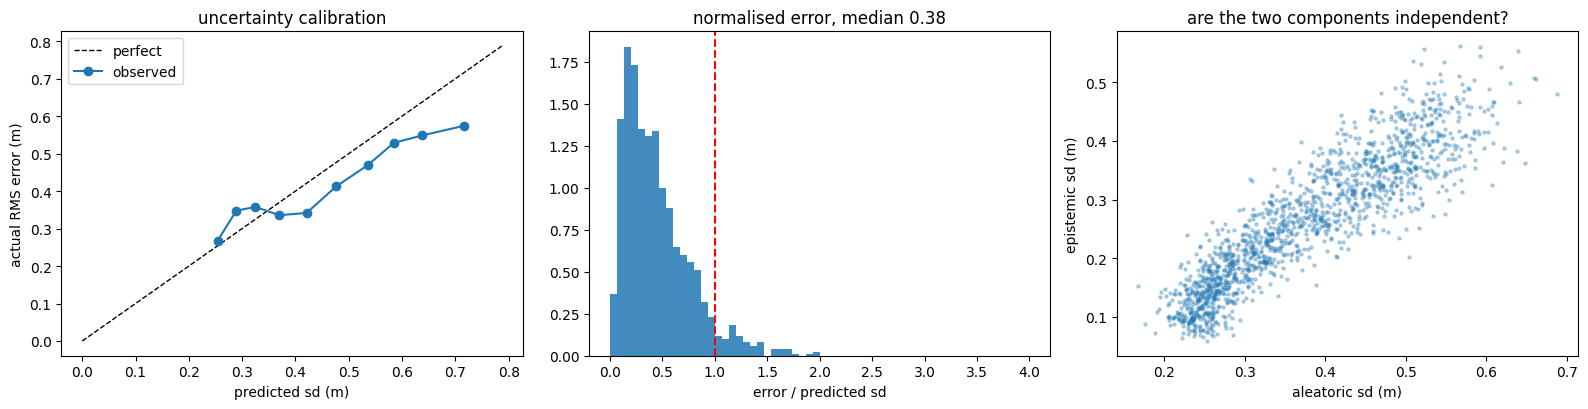

median normalised error 0.377  (above 1 means overconfident)
correlation between error and predicted sd: +0.304


In [ ]:
sd_tot = np.sqrt(mc_syn["aleatoric"] + mc_syn["epistemic"]).mean(1)
qs = np.quantile(sd_tot, np.linspace(0, 1, 11))
cx, cy = [], []
for i in range(10):
    m_ = (sd_tot >= qs[i]) & (sd_tot < qs[i+1] if i < 9 else sd_tot <= qs[i+1])
    if m_.sum() < 5: continue
    cx.append(sd_tot[m_].mean()); cy.append(np.sqrt((err[m_]**2).mean()))

z = err / np.maximum(sd_tot * np.sqrt(3), 1e-9)
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))
lim = max(max(cx), max(cy)) * 1.1
axes[0].plot([0, lim], [0, lim], "k--", lw=1, label="perfect")
axes[0].plot(cx, cy, "o-", label="observed")
axes[0].set_xlabel("predicted sd (m)"); axes[0].set_ylabel("actual RMS error (m)")
axes[0].set_title("uncertainty calibration"); axes[0].legend()
axes[1].hist(z, bins=60, range=(0, 4), density=True, alpha=.85)
axes[1].axvline(1.0, c="r", ls="--"); axes[1].set_xlabel("error / predicted sd")
axes[1].set_title(f"normalised error, median {np.median(z):.2f}")
axes[2].scatter(sd_a.mean(1), sd_e.mean(1), s=5, alpha=.3)
axes[2].set_xlabel("aleatoric sd (m)"); axes[2].set_ylabel("epistemic sd (m)")
axes[2].set_title("are the two components independent?")
plt.tight_layout(); plt.show()
print(f"median normalised error {np.median(z):.3f}  (above 1 means overconfident)")
print(f"correlation between error and predicted sd: {np.corrcoef(err, sd_tot)[0,1]:+.3f}")

## 4. Does epistemic uncertainty detect the domain gap?

No labels enter this test. The model is shown the synthetic validation images and the
two hardware-in-the-loop domains, and the only quantity compared is how much it
disagrees with itself across stochastic passes.

The prediction is directional and therefore falsifiable: epistemic uncertainty should
rise on lightbox and sunlamp, since those images are outside the training
distribution, while aleatoric uncertainty changes for a separate reason, namely that
the images are harder to see in. If the two move together, or if epistemic moves the
wrong way, the decomposition is not carrying the meaning claimed for it.

domain        aleatoric sd   epistemic sd  epistemic ratio
synthetic           0.375 m         0.262 m            1.00x
lightbox            0.135 m         0.170 m            0.65x
sunlamp             0.140 m         0.171 m            0.65x


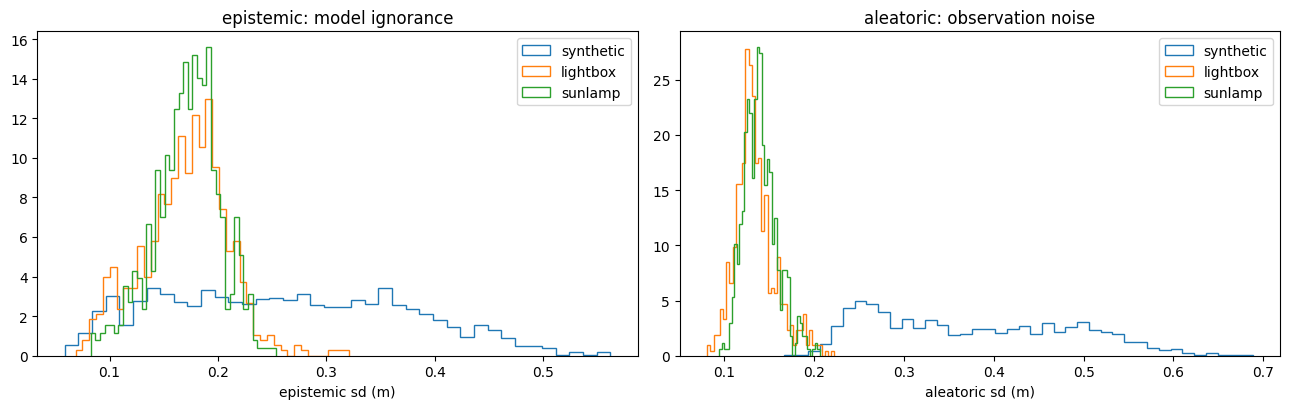

In [ ]:
rows = [("synthetic", mc_syn)] + list(mc_hil.items())
print(f"{'domain':<12}{'aleatoric sd':>14}{'epistemic sd':>15}{'epistemic ratio':>17}")
base_e = np.sqrt(mc_syn["epistemic"]).mean()
summary = {}
for name, mc in rows:
    a = np.sqrt(mc["aleatoric"]).mean(); e = np.sqrt(mc["epistemic"]).mean()
    summary[name] = (a, e, np.sqrt(mc["epistemic"]).mean(1))
    print(f"{name:<12}{a:>13.3f} m{e:>14.3f} m{e/max(base_e,1e-9):>16.2f}x")

fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))
for name, mc in rows:
    axes[0].hist(np.sqrt(mc["epistemic"]).mean(1), bins=40, density=True,
                 histtype="step", lw=1.8, label=name)
    axes[1].hist(np.sqrt(mc["aleatoric"]).mean(1), bins=40, density=True,
                 histtype="step", lw=1.8, label=name)
axes[0].set_xlabel("epistemic sd (m)"); axes[0].set_title("epistemic: model ignorance")
axes[1].set_xlabel("aleatoric sd (m)"); axes[1].set_title("aleatoric: observation noise")
for a in axes: a.legend()
plt.tight_layout(); plt.show()

### Scoring it as a detector

If epistemic uncertainty is useful for this, it should separate synthetic from HIL
images on its own. That is a binary decision with no labels involved, so it can be
scored with an ROC curve where the positive class is simply "this image came from the
HIL domain".

An area near 0.5 means the signal carries no information about the shift. A high area
means a model could flag, in flight, that it is being shown something unlike its
training data, which is the operationally useful version of this.

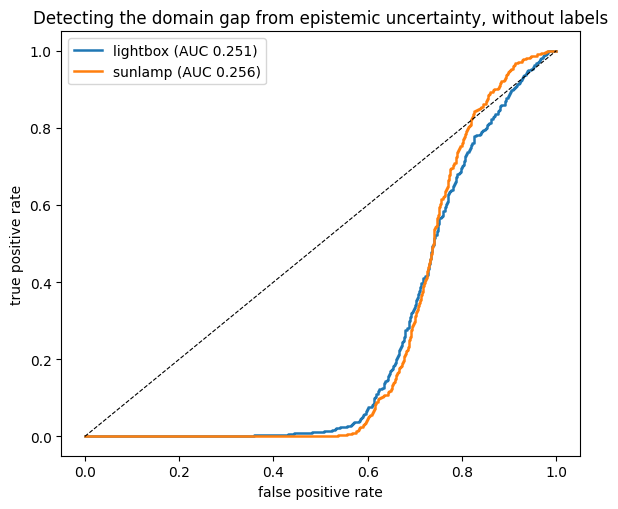

In [ ]:
from sklearn.metrics import roc_curve, auc
e_syn = summary["synthetic"][2]
plt.figure(figsize=(6, 5.2))
for name in [d for d in summary if d != "synthetic"]:
    e_out = summary[name][2]
    y = np.r_[np.zeros(len(e_syn)), np.ones(len(e_out))]
    s = np.r_[e_syn, e_out]
    fpr, tpr, _ = roc_curve(y, s)
    plt.plot(fpr, tpr, lw=1.8, label=f"{name} (AUC {auc(fpr,tpr):.3f})")
plt.plot([0,1],[0,1],"k--",lw=.8)
plt.xlabel("false positive rate"); plt.ylabel("true positive rate")
plt.title("Detecting the domain gap from epistemic uncertainty, without labels")
plt.legend(); plt.tight_layout(); plt.show()

## 5. A covariance for the filter

 For each image the total predictive variance gives a diagonal
measurement covariance R in metres squared, which is what a relative navigation filter
consumes. Experiment 6 carries this idea forward.

In [ ]:
R_diag = mc_syn["aleatoric"] + mc_syn["epistemic"]
print("median predicted measurement sd per axis (m):", np.sqrt(np.median(R_diag, axis=0)).round(3))
np.save("R_from_uncertainty.npy", R_diag)
np.save("err_synthetic.npy", mc_syn["t_mean"] - Tva)
print("saved R_from_uncertainty.npy and err_synthetic.npy for Experiment 6")

median predicted measurement sd per axis (m): [0.107 0.132 1.118]
saved R_from_uncertainty.npy and err_synthetic.npy for Experiment 6


## 6. Results

**The network learns which axis it cannot observe.** Predicted aleatoric standard
deviation is [0.097, 0.121, 0.906] m per axis and epistemic is [0.048, 0.069, 0.670] m.
The boresight component is seven to nine times the lateral components, without
supervision on that split. This matches the 4.2x error anisotropy measured directly in
Experiment 4 and reproduces, from the model side, the reason range is taken from a
laser rangefinder rather than from a camera in cooperative docking designs.

**On the synthetic domain the model is underconfident.** The median ratio of actual
error to predicted standard deviation is 0.38, and the calibration curve sits below
the diagonal: errors are consistently smaller than the predicted error bars. The
correlation between actual error and predicted standard deviation is +0.304, so the
uncertainty carries real information about which images are hard, but its scale is
too wide.

**The two components are not independent.** The scatter of epistemic against aleatoric
standard deviation is close to linear. The decomposition is separating the arithmetic
but not two distinct sources, so the epistemic term here should be read as a measure of
the model's sensitivity to dropout rather than as a clean estimate of distributional
distance.

**Epistemic uncertainty does not detect the domain gap. It moves the wrong way.**
Mean epistemic standard deviation is 0.262 m on synthetic against 0.170 m on lightbox
and 0.171 m on sunlamp, a ratio of 0.65. Scored as a detector the areas under the ROC
curve are 0.251 and 0.256, both below the 0.5 of an uninformative signal. The model is
systematically more confident on the two domains where Experiment 4 measured its
translation error to be 14.5 and 15.4 times larger.

**The mechanism is visible in Experiment 4.** On the hardware-in-the-loop domains the
predicted range collapses onto a narrow peak near 2.2 m, and the model returns nearly
the same answer regardless of the image. Monte Carlo dropout measures disagreement
between stochastic passes; when the network has collapsed to a near-constant output,
those passes agree, and the epistemic estimate reads low. Prediction collapse presents
as confidence.

This is the same failure mode found in the study for Experiments 1, 2, and 3, where the learned detector was
the worst calibrated of the three, now measured at the level of a whole domain rather
than a single frame. An area of 0.25 also means the signal is informative once
inverted, but a detector that must be inverted is not one that can be trusted on a
domain it has not been calibrated against.

### Limitations

The backbone is a ResNet-18 trained on 8,000 synthetic images for 15 epochs, so the
result describes this model rather than the method in general. Monte Carlo dropout is a
cheap approximation to a posterior; a deep ensemble is the stronger estimator and the
two are known to disagree, so the negative result here does not settle the question for
epistemic uncertainty as such. Dropout is present only in the head, so the backbone
contributes nothing to the disagreement, which likely understates the estimate.